In [37]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [38]:
from pathlib import Path

In [39]:
img_path = Path("animal-clef-2026")

In [40]:
train_dir = img_path / "train"
test_dir = img_path / "test"

In [41]:
img_list = list(train_dir.glob("*/*/*.jpg"))
img_list

[WindowsPath('animal-clef-2026/train/LynxID2025/00/2346ca29481a60d38806e52a3e8aaebea2a2293838961ab9cc70bd6c03f9b769.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/00/47a04afea9a27f2e9987bd90b52c6566820af1ca3db87a9d11bd217a1375a07b.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/00/b01355f85b2811cbe4c866d35d2714e636cbca5d9cdc3fcb2d155e1465a3c097.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/00/c0946cd20fd6ba61a623d75f0c561d4a158d41016c1675c6baab4934460c6f18.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/00/ca193791069939ef89382f6eeff22b73326726751b5004e5f2c2dd22d42be6c8.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/00/e380653385d8f1fd317f8e51b7f4c788ca62b1480752d8a91f84dd3a52aca69c.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/01/022d98e070b0c1c7b38a4815bd5d4a971c9a838c1547f8bec7e18734482b24ac.jpg'),
 WindowsPath('animal-clef-2026/train/LynxID2025/01/196f33f4f503a5ed11733b92de608416faa0657dc7330e95b2153fddfd0758df.jpg'),
 WindowsPath('an

In [42]:
len(img_list)

11585

In [43]:
import random
a = random.choice(img_list)

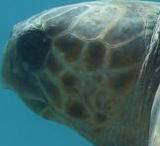

In [44]:
from PIL import Image
Image.open(a)

In [45]:
import os

In [46]:
for dirpath , dirnames , filenames in os.walk(img_path):
    print(f"images = {len(filenames)} , folders = {len(dirnames)} in path {dirpath}")

images = 0 , folders = 2 in path animal-clef-2026
images = 0 , folders = 4 in path animal-clef-2026\test
images = 946 , folders = 0 in path animal-clef-2026\test\LynxID2025
images = 689 , folders = 0 in path animal-clef-2026\test\SalamanderID2025
images = 500 , folders = 0 in path animal-clef-2026\test\SeaTurtleID2022
images = 83 , folders = 0 in path animal-clef-2026\test\TexasHornedLizards
images = 0 , folders = 4 in path animal-clef-2026\train
images = 0 , folders = 77 in path animal-clef-2026\train\LynxID2025
images = 6 , folders = 0 in path animal-clef-2026\train\LynxID2025\00
images = 28 , folders = 0 in path animal-clef-2026\train\LynxID2025\01
images = 2 , folders = 0 in path animal-clef-2026\train\LynxID2025\02
images = 75 , folders = 0 in path animal-clef-2026\train\LynxID2025\03
images = 3 , folders = 0 in path animal-clef-2026\train\LynxID2025\04
images = 151 , folders = 0 in path animal-clef-2026\train\LynxID2025\05
images = 113 , folders = 0 in path animal-clef-2026\train

In [47]:
import torch.nn as nn
from torchvision import transforms , datasets
from torch.utils.data import DataLoader

In [48]:
def train_step(acc_fn , model : nn.Module , optimizer , loss_fn : nn.Module , dataloader  ):
    acc_fn.reset()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    acc_fn = acc_fn.to(device)
    loss_fn  = loss_fn.to(device)
    l = len(dataloader)
    train_loss = 0
    train_acc = 0 
    model.train()
    for batch , (x,y) in enumerate(dataloader):
        x , y = x.to(device) , y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred , y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        acc = acc_fn(y_pred , y)
        train_acc += acc.item()
    train_loss = train_loss / l
    train_acc = train_acc / l
    return train_loss , train_acc

In [49]:
def test_step(acc_fn , model : nn.Module , loss_fn : nn.Module , dataloader  ):
    acc_fn.reset()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    acc_fn = acc_fn.to(device)
    loss_fn  = loss_fn.to(device)
    l = len(dataloader)
    test_loss = 0
    test_acc = 0 
    model.eval()
    with torch.inference_mode():
        
        for batch , (x,y) in enumerate(dataloader):
            x , y = x.to(device) , y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred , y)
            test_loss += loss.item()
            acc = acc_fn(y_pred , y)
            test_acc += acc.item()
    test_loss = test_loss / l
    test_acc = test_acc / l
    return test_loss , test_acc

## using efficient net 

### B 0 model first

In [50]:
import torchvision

In [51]:
w0 = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [52]:
m0 = torchvision.models.efficientnet_b0(weights = w0)

In [53]:
t0 = w0.transforms()

In [54]:
train_stack0 = datasets.ImageFolder(root = train_dir , transform = t0 , target_transform = None )
test_stack0 = datasets.ImageFolder(root = test_dir , transform = t0 , target_transform = None )

In [55]:
train_dl0 = DataLoader(dataset = train_stack0 , shuffle = True , batch_size = 32)
test_dl0 = DataLoader(dataset = test_stack0 , shuffle = True , batch_size = 32)

In [56]:
len(train_dl0) , len(test_dl0)

(415, 70)

In [57]:
from torchinfo import summary
summary(m0 , input_size = (32,3,255,255))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1280, 8, 8]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 128, 128]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 128, 128]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 128, 128]        64
│    │    └─SiLU: 3-3                                   [32, 32, 128, 128]        --
│    └─Sequential: 2-2                                  [32, 16, 128, 128]        --
│    │    └─MBConv: 3-4                                 [32, 16, 128, 128]        1,448
│    └─Sequential: 2-3                                  [32, 24, 64, 64]          --
│    │    └─MBConv: 3-5                                 [32, 24, 64, 64]          6,004
│    │    └─MBConv: 3-6                              

In [58]:
infeature = m0.classifier[1].in_features

In [59]:
infeature

1280

In [60]:
classes = train_stack0.classes
classes

['LynxID2025', 'SalamanderID2025', 'SeaTurtleID2022', 'TexasHornedLizards']

In [61]:
img , label = next(iter(train_dl0))
img.shape

torch.Size([32, 3, 224, 224])

In [62]:
a = img[0].permute(1,2,0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.367669].


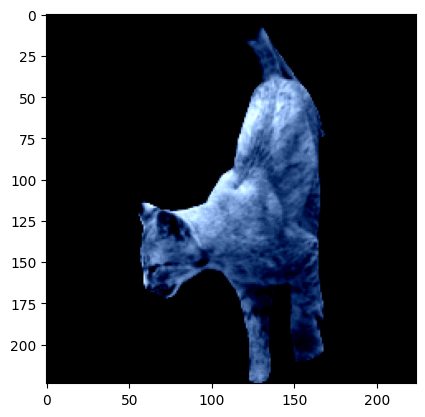

In [63]:
import matplotlib.pyplot as plt
plt.imshow(a) 

In [64]:
m0.classifier = nn.Sequential(nn.Dropout(p=0.3),nn.Linear(infeature, len(classes)))

In [65]:
train_stack0.class_to_idx

{'LynxID2025': 0,
 'SalamanderID2025': 1,
 'SeaTurtleID2022': 2,
 'TexasHornedLizards': 3}

In [66]:
from tqdm.auto import tqdm

In [67]:
from torchmetrics import Accuracy 
acc_fn = Accuracy(task = "multiclass" , num_classes = len(classes))

In [68]:
import torch

In [69]:
for param in m0.features.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam( m0.classifier.parameters(),lr=0.0001,weight_decay=1e-4)

In [70]:
loss_fn = nn.CrossEntropyLoss()

In [71]:
epochs = 3
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , m0 , optimizer , loss_fn  , train_dl0 )
    print(f"epoch = {epoch} train loss = {v1} train acc = {v2} \n\n")
    u1 , u2 = test_step(acc_fn , m0 , loss_fn , test_dl0  )
    print(f"epoch = {epoch} test loss = {u1} test acc = {u2} \n\n")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch = 0 train loss = 0.5053429564797735 train acc = 0.8718550673450333 


epoch = 0 test loss = 0.25641467507396426 test acc = 0.9647321428571428 


epoch = 1 train loss = 0.1720391276011984 train acc = 0.9777861445783133 


epoch = 1 test loss = 0.11206026391259262 test acc = 0.988749999659402 


epoch = 2 train loss = 0.10281589043337896 train acc = 0.989683734939759 


epoch = 2 test loss = 0.06359746594514165 test acc = 0.9941964285714285 




###  now using efficient net b3 model

In [72]:
w2 = torchvision.models.EfficientNet_B3_Weights.DEFAULT

In [73]:
m2 = torchvision.models.efficientnet_b3(weights = w2)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\divyadarshee dash/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth


100%|█████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:24<00:00, 2.00MB/s]


In [74]:
trans2 =  w2.transforms()

In [75]:
train_stack2 = datasets.ImageFolder(root = train_dir , transform = trans2 )
test_stack2 = datasets.ImageFolder(root = test_dir , transform = trans2 )

In [76]:
train_dl2 = DataLoader(dataset = train_stack2 , shuffle = True , batch_size = 32)
test_dl2 = DataLoader(dataset = test_stack2 , shuffle = True , batch_size = 32)

In [77]:
summary(m2 , input_size = (32,3,255,255))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1536, 8, 8]          --
│    └─Conv2dNormActivation: 2-1                        [32, 40, 128, 128]        --
│    │    └─Conv2d: 3-1                                 [32, 40, 128, 128]        1,080
│    │    └─BatchNorm2d: 3-2                            [32, 40, 128, 128]        80
│    │    └─SiLU: 3-3                                   [32, 40, 128, 128]        --
│    └─Sequential: 2-2                                  [32, 24, 128, 128]        --
│    │    └─MBConv: 3-4                                 [32, 24, 128, 128]        2,298
│    │    └─MBConv: 3-5                                 [32, 24, 128, 128]        1,206
│    └─Sequential: 2-3                                  [32, 32, 64, 64]          --
│    │    └─MBConv: 3-6                            

In [78]:
infeature = m2.classifier[1].in_features

In [79]:
m2.classifier = nn.Sequential(nn.Dropout(p=0.3),nn.Linear(infeature, len(classes)))

In [80]:
for param in m2.features.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam( m2.classifier.parameters(),lr=0.0001,weight_decay=1e-4)

In [81]:
epochs = 3
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , m2 , optimizer , loss_fn  , train_dl2 )
    print(f"epoch = {epoch} train loss = {v1} train acc = {v2} \n\n")
    u1 , u2 = test_step(acc_fn , m2 , loss_fn , test_dl2  )
    print(f"epoch = {epoch} test loss = {u1} test acc = {u2} \n\n")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch = 0 train loss = 0.499313851113779 train acc = 0.8892319277108434 


epoch = 0 test loss = 0.3336124986410141 test acc = 0.9705357142857143 


epoch = 1 train loss = 0.15859192911400852 train acc = 0.9805058469255287 


epoch = 1 test loss = 0.12419350551707405 test acc = 0.9897321428571428 


epoch = 2 train loss = 0.08968801039259836 train acc = 0.9900779589112982 


epoch = 2 test loss = 0.06831900386938027 test acc = 0.9995535714285714 




## using model b4

In [82]:
w4 = torchvision.models.EfficientNet_B4_Weights.DEFAULT

In [83]:
m4 = torchvision.models.efficientnet_b4(weights = w4)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to C:\Users\divyadarshee dash/.cache\torch\hub\checkpoints\efficientnet_b4_rwightman-23ab8bcd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 74.5M/74.5M [00:14<00:00, 5.22MB/s]


In [84]:
trans4 =  w4.transforms()

In [85]:
train_stack4 = datasets.ImageFolder(root = train_dir , transform = trans4 )
test_stack4 = datasets.ImageFolder(root = test_dir , transform = trans4 )

In [86]:
train_dl4 = DataLoader(dataset = train_stack4 , shuffle = True , batch_size = 32)
test_dl4 = DataLoader(dataset = test_stack4 , shuffle = True , batch_size = 32)

In [87]:
summary(m4 , input_size = (32,3,255,255))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1792, 8, 8]          --
│    └─Conv2dNormActivation: 2-1                        [32, 48, 128, 128]        --
│    │    └─Conv2d: 3-1                                 [32, 48, 128, 128]        1,296
│    │    └─BatchNorm2d: 3-2                            [32, 48, 128, 128]        96
│    │    └─SiLU: 3-3                                   [32, 48, 128, 128]        --
│    └─Sequential: 2-2                                  [32, 24, 128, 128]        --
│    │    └─MBConv: 3-4                                 [32, 24, 128, 128]        2,940
│    │    └─MBConv: 3-5                                 [32, 24, 128, 128]        1,206
│    └─Sequential: 2-3                                  [32, 32, 64, 64]          --
│    │    └─MBConv: 3-6                            

In [88]:
infeature = m4.classifier[1].in_features

In [89]:
m4.classifier = nn.Sequential(nn.Dropout(p=0.3),nn.Linear(infeature, len(classes)))

In [90]:
for param in m4.features.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam( m4.classifier.parameters(),lr=0.0001,weight_decay=1e-4)

In [91]:
epochs = 3
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , m4 , optimizer , loss_fn  , train_dl4 )
    print(f"epoch = {epoch} train loss = {v1} train acc = {v2} \n\n")
    u1 , u2 = test_step(acc_fn , m4 , loss_fn , test_dl4  )
    print(f"epoch = {epoch} test loss = {u1} test acc = {u2} \n\n")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch = 0 train loss = 0.8276351178985044 train acc = 0.9313253012048193 


epoch = 0 test loss = 0.5788785125528063 test acc = 0.95 


epoch = 1 train loss = 0.35062427894178644 train acc = 0.9789909638554217 


epoch = 1 test loss = 0.3328387586133821 test acc = 0.9616071428571429 


epoch = 2 train loss = 0.20696511011884874 train acc = 0.983433734939759 


epoch = 2 test loss = 0.2071032681635448 test acc = 0.9700892857142858 




In [92]:
model = Path("models")
model.mkdir(parents = True , exist_ok = True)
mode_save = model / "animal_classifier.pth"
torch.save(obj = m2.state_dict() , f = mode_save)

In [94]:
tester = Path("tester")
tester_img = list(tester.glob("*.jpg"))
len(tester_img)

2

In [103]:
tester_img.append("tester/OceanImageBank_LewisBurnett_10_v32_CMYK.webp")

In [104]:
tester_img.append("tester/Untitled-design-4.webp")

In [105]:
len(tester_img)

6

In [107]:
tester_ = datasets.ImageFolder(root = tester , transform = trans2 , target_transform = None)
data = DataLoader(dataset = tester_ , batch_size = 1 , shuffle = True)

In [110]:
train_stack0.class_to_idx

{'LynxID2025': 0,
 'SalamanderID2025': 1,
 'SeaTurtleID2022': 2,
 'TexasHornedLizards': 3}

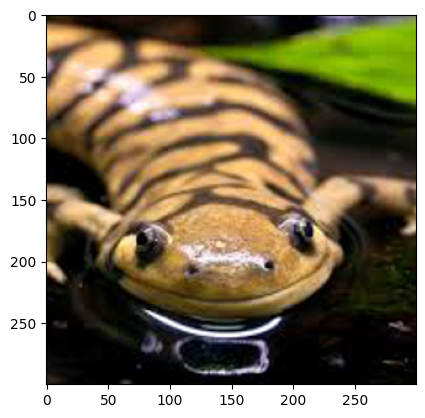

Salamander


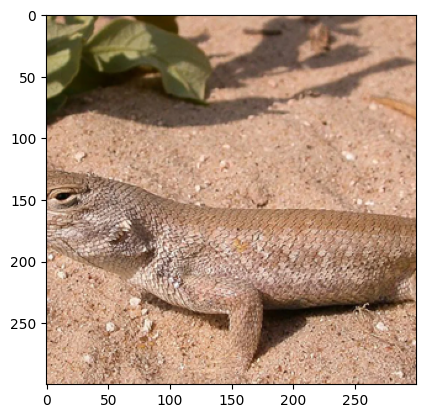

TexasHornedLizards


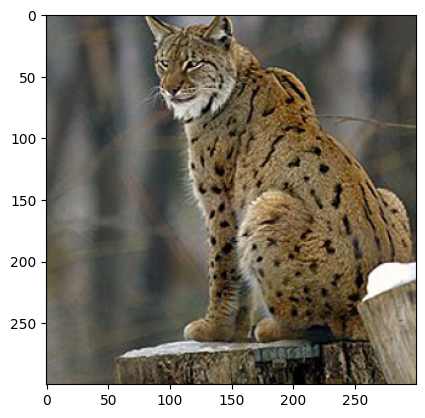

Lynx


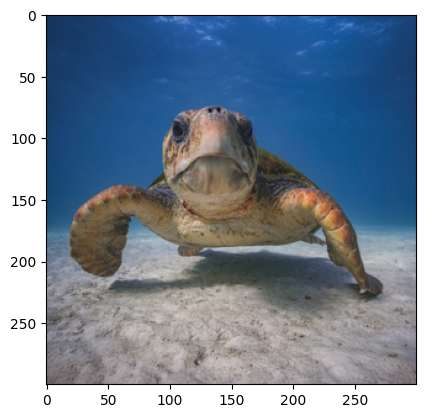

SeaTurtle


In [115]:
m2.eval()
m2 = m2.to("cuda")
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

with torch.inference_mode():
    for batch , (x,y) in enumerate(data):
        x,y = x.to("cuda") , y.to("cuda")
        img = x.squeeze().cpu().permute(1,2,0)
        img = img * std + mean
        img = img.clamp(0,1)
        plt.imshow(img)
        plt.show()
        y_pred = m2(x)
        classes = torch.argmax(y_pred, dim=1).item()

        if classes == 0:
            print("Lynx")
        elif classes == 1:
            print("Salamander")
        elif classes == 2:
            print("SeaTurtle")
        elif classes == 3:
            print("TexasHornedLizards")
        else:
            print("unable to get")
